##### Lab 3: Data Planning and Preprocessing
Suggested time: **35 minutes**

Accelerator : **CPU**

This lab walks us through the typical steps for preprocessing acoustic data to make it suitable for supervised training. While your mileage will vary depending on your application and ecosystem, it turns out that **Python** is adept at handling common steps in **an OS-agnostic way**:
- organizing your samples/category as folders hierarchy
- calling external tools to perform the audio-processing (information on the audio file, convert to single channel, filtering, create spectrogram...)

The goal of this lab is to show you:
- some useful modules/APIs from the Python standard library for working with (data) files.
- how you could run external commands from your Python script.
- some useful modules/APIs to visualize your data in Python.

##### **Step 0**: Upload and unzip relevant audio files from AWS cloud storage

In [0]:
%%bash

wget -qq https://edge-ai-doulos.s3.us-west-2.amazonaws.com/Edge-AI-Upload.zip
unzip -qq Edge-AI-Upload.zip


#### **Step 1.** Working with folders
The cell below shows how to use the **os** and **shutil** modules to:
- [os.chdir()](https://docs.python.org/3/library/os.html#os.chdir) to change to the home directory `/content`
- [os.mkdir()](https://docs.python.org/3/library/os.html#os.mkdir) to create (sub-)directories.
- [os.listdir()](https://docs.python.org/3/library/os.html#os.listdir) to list the content of the current working directory.
- [shutil.rmtree()](https://docs.python.org/3/library/shutil.html#shutil.rmtree) to remove an existing folder (including contents and subfolders)


Create a directory called 'Acoustic-Training' inside '/content' (Colab's default working directory). Go on and create multiple subdirectories inside 'Acoustic-Training' to store different audio files. We will create a file structure that looks like,

```
Acoustic-Training
├── trumpet
│   ├── trumpet1.wav
│   ├── trumpet1.png
│   └── ...
├── guitar
│   ├── guitar1.wav
│   ├── guitar1.png
│   └── ...
└── ...
```

In [0]:
import os
import shutil

home = os.getcwd()
training_dir_path = os.path.join(home, 'Acoustic-Training')

"""
create training_dir in $HOME.
If it already exists => nuke content
"""
if os.path.exists(training_dir_path):
    shutil.rmtree(training_dir_path)
os.mkdir(training_dir_path)

"""create one folder per category"""
print(f"Create sound categories in {training_dir_path}")
categories=["trumpet", "violin", "ocean-waves", "saxophone-weep", "guitar"]
for folder in categories:
    folder_path = os.path.join(training_dir_path, folder)
    print(f"    {folder =}")
    os.mkdir(folder_path)

"""Sanity check"""
print(f"\ncontent of {training_dir_path}:\n{os.listdir(training_dir_path)}")

**Quick Check:**  Use the Explorer to verify that the directories got created.

##### **Step 2:** Paths manipulation, file copy and more

Python offers the **os.path** to manipulate pathname in a OS-independent manner (so we don't have to worry about the folder separator `\`, `/`, `¥`, `₩` etc. depending on the OS and locals).

The cell below illustrates the use of:
- [os.path](https://docs.python.org/3/library/os.path.html) module to work with pathnames
- [shutil.copyfile]() to copy file

Run the cell below.<br>
Make sure you're understand the Python code, in particular the use of:
- from ... import
- [zip()](https://docs.python.org/3/library/functions.html#zi) built-in function to iterate over lists in parallel in a pythonic way.

In [0]:
import os
from shutil import copyfile

base_content_dir = os.getcwd()
audio_source_dir = os.path.join(base_content_dir, 'Audio')
training_root_dir = os.path.join(base_content_dir, 'Acoustic-Training')

"""
copy the audio file to their corresponding categories
"""
audio_files = ["trumpet.wav", "violin.wav", "ocean-waves.wav", "saxophone-weep.wav", "guitar.wav"]
categories = ["trumpet", "violin", "ocean-waves", "saxophone-weep", "guitar"]

for file, folder in zip(audio_files, categories):
    src = os.path.join(audio_source_dir, file)
    dst_folder = os.path.join(training_root_dir, folder)
    print(f"copy\n  from: {src}\n  to  : {dst_folder}")
    shutil.copy(src, dst_folder)

#### Verify your result:
The cell below shows how to run a shell command from your Notebook using the  `!command` syntax.<br>Run the following cell to verify that the .wav files have been indeed copied to your dataset folder. We're using here the tree Linux shell command to that aim.

In [0]:
#!apt -q install tree > /dev/null 2>&1
!tree -L 2 Acoustic-Training

##### **Step 3:** Using Python subprocess.run to run external commands
- subprocess.run() allows execution of command line instructions (cli) from Python.
- we use subprocess.run() to run commands from Sound eXchange(SoX) to analyze sound.
- get some experience using subprocess.run() by listing compressed files (.zip) in /content directory.
- plotting spectrogram
- importance of visualizing data, and where matplotlib is super useful.


In [0]:
import os, subprocess

base_dir= os.getcwd()

args_cli =(f'ls -l {base_dir}')
result = subprocess.run(args = args_cli, capture_output = True, shell= True, universal_newlines=True)

print (result.stdout)

##### Your Turn : Exercise

Use subprocess.run() to print out .wav files in */content/Audio* directory.

##### Solution

If you want to see our answer, click below.  You can copy and paste the solution to a new code cell for trying it out. 

<details>
    <summary> Click here for our answer </summary>
    
    import os, subprocess

    home = os.getcwd()

    base_dir= os.path.join(home, 'Audio')

    args_cli =(f'ls {base_dir}/*.wav')
    result = subprocess.run(args = args_cli, capture_output = True, shell= True, universal_newlines=True)

    print (result.stdout)

    
</details>

#####  **Step 4**:  Install and use Sound eXchange (SoX) for image preprocessing. Subsequent cells use SoX CLI commands and subprocess.run(). Refer to [Sox documentation](https://manpages.org/sox) for more details.

- First check is check is installed. If it is not installed, run the subsequent install cell by uncommenting it

In [0]:
!sox

In [0]:
#!apt-get -q install sox > /dev/null 2>&1

#### **Step 4(a):** Audio Trim, Mono and Spectrogram creation using SoX

The next two cells demonstrate use of audio trim (converting sound to smaller duration snippets), conversion of studio sound to mono and conversation of audio .wav file to Spectrogram of size 224 x 224 pixels.

In [0]:
import subprocess
import os

home = os.getcwd()

base_dir = os.path.join(home, 'Acoustic-Training', 'trumpet')

for i in range (8):
    input_wav = os.path.join(base_dir, 'trumpet.wav')
    output_wav = os.path.join(base_dir, f'trumpet{i}.wav')
    args_cli =(f'sox {input_wav} {output_wav} trim {i} {i+1}')
    subprocess.run(args = args_cli, capture_output = True, shell= True, universal_newlines=True)

input_wav = os.path.join(base_dir, 'trumpet.wav')
output_mono_wav = os.path.join(base_dir, 'trumpet_mono.wav')
args_cli = (f'sox {input_wav} {output_mono_wav} remix 1')
subprocess.run(args = args_cli, capture_output = True, shell= True, universal_newlines=True)

os.listdir(base_dir)

In [0]:
import subprocess
import os, shutil

home = os.getcwd()

base_dir = os.path.join(home, 'Acoustic-Training', 'trumpet')

for i in range (8):
    input_wav = os.path.join(base_dir, f'trumpet{i}.wav')
    output_png = os.path.join(base_dir, f'trumpet{i}.png')
    args_cli =(f'sox {input_wav} -n rate 44k spectrogram -x 224 -y 224 -q 5 -o {output_png}')
    subprocess.run(args = args_cli, capture_output = True, shell= True, universal_newlines=True)

os.listdir(base_dir)

#### **Step 4(b):** Plot Spectrograms using Matplotlib:

Here we plot 8 spectrograms of one second duration Trumpet sound. The two spectrograms (top and bottom) represent the left and right channels of stereo sound.  

In [0]:
import os, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

home = os.getcwd()

base_dir = os.path.join(home, 'Acoustic-Training', 'trumpet')

os.listdir(base_dir)

for i in range(8):
    filename_png = os.path.join(base_dir, f'trumpet{i}.png')
    image = mpimg.imread(filename_png)
    plt.figure()
    plt.imshow(image)

#### **Step 4(c):**  Convert Stereo to Mono sound and obtain file details

The bash commands below are used to convert a stereo recorded sound to mono sound.  File size is reduced after this conversion.

In [0]:
%%script bash

home=$(pwd)
SOX_BASE_DIR="$home/Acoustic-Training/trumpet"

sox "${SOX_BASE_DIR}/trumpet.wav" "${SOX_BASE_DIR}/trumpet_mono.wav" remix 1  # Convert trumpet stereo sound to mono by remixing to single channel (1)
sox --info "${SOX_BASE_DIR}/trumpet_mono.wav"

#### **Step 4(d):** Filter sound to focus on frequency of interest

SoX supports use of different types of filter. Here the use of a low pass filter (with cutoff frequency of 3000 Hz) is demonstrated.

In [0]:
import subprocess,os

os.path.join(home, 'Acoustic-Training', 'trumpet')

base_dir = os.path.join(home, 'Acoustic-Training', 'trumpet')

input_mono_wav = os.path.join(base_dir, 'trumpet_mono.wav')
output_filter_wav = os.path.join(base_dir, 'trumpet-filter.wav')
result = subprocess.run(args = f'sox {input_mono_wav} {output_filter_wav} lowpass 3000.0', capture_output = True, shell= True, universal_newlines=True)

print (result.stdout)

#### Questions:

- Why is filtering used to preprocess a sound file before using it for model training?
- Is this preprocessing needed only for training?


#### Solution

Click below if you wish to see our answer.

<details>
    <summary> Click here </summary>

    - Filtering removes background noise which we do not want AI model to learn
    - This preprocessing step is also required when model is executed (or during inference).
    
</details>



#### **Step 4(e):** Create and view Spectrograms of original and filtered Trumpet sound

The two cells below use SoX commands and Matplotlib to create and plot spectrograms of unfiltered and filtered mono trumpet sound.

In [0]:
%%script bash

home=$(pwd)
SOX_BASE_DIR="$home/Acoustic-Training/trumpet"

sox "${SOX_BASE_DIR}/trumpet-filter.wav" -n rate 44k spectrogram -x 224 -y 224 -q 5 -r -o "${SOX_BASE_DIR}/trumpet-filter.png"
sox "${SOX_BASE_DIR}/trumpet_mono.wav" -n rate 44k spectrogram -x 224 -y 224 -q 5 -r -o "${SOX_BASE_DIR}/trumpet_mono.png"

In [0]:
import os, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

home = os.getcwd()

base_dir = os.path.join(home, 'Acoustic-Training', 'trumpet')

plt.subplot (1,2,1)
filename_png = os.path.join(base_dir, f'trumpet_mono.png')
image = mpimg.imread(filename_png)
plt.title('Unfiltered Spectrogram')
plt.imshow(image)

plt.subplot (1,2,2)
filename_png = os.path.join(base_dir, f'trumpet-filter.png')
image = mpimg.imread(filename_png)
plt.title('Filtered Spectrogram')
plt.imshow(image)

Experiment with number of Spectrogram colors:

- The -q 5 parameter while creating the spectrogram determines the number of colors used in the spectrogram.
- Increase the number and see how the spectrogram changes.

#####  Uniform Manifold Approximation and Projection (UMAP) for Dimensionality Reduction

Resource: [UMAP Documentation](https://umap-learn.readthedocs.io/en/latest/index.html)

UMAP (Uniform Manifold Approximation and Projection) effectively projects high-dimensional embeddings into 2D, frequently confirming dataset distribution by creating distinct, interpretable clusters that represent local neighborhoods and global structures. While excellent for visualization, it is a non-linear, stochastic dimensionality reduction technique and may distort exact distances, meaning clusters in 2D do not technically prove the exact underlying distribution, though they provide a reliable approximation of topological structures

In [6]:
!pip install -q umap-learn seaborn palmerpenguins


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Loading MNIST dataset (this might take a moment)...


Dataset shape: (10000, 784)
Running UMAP dimensionality reduction...


/ext/venvs/cocalc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


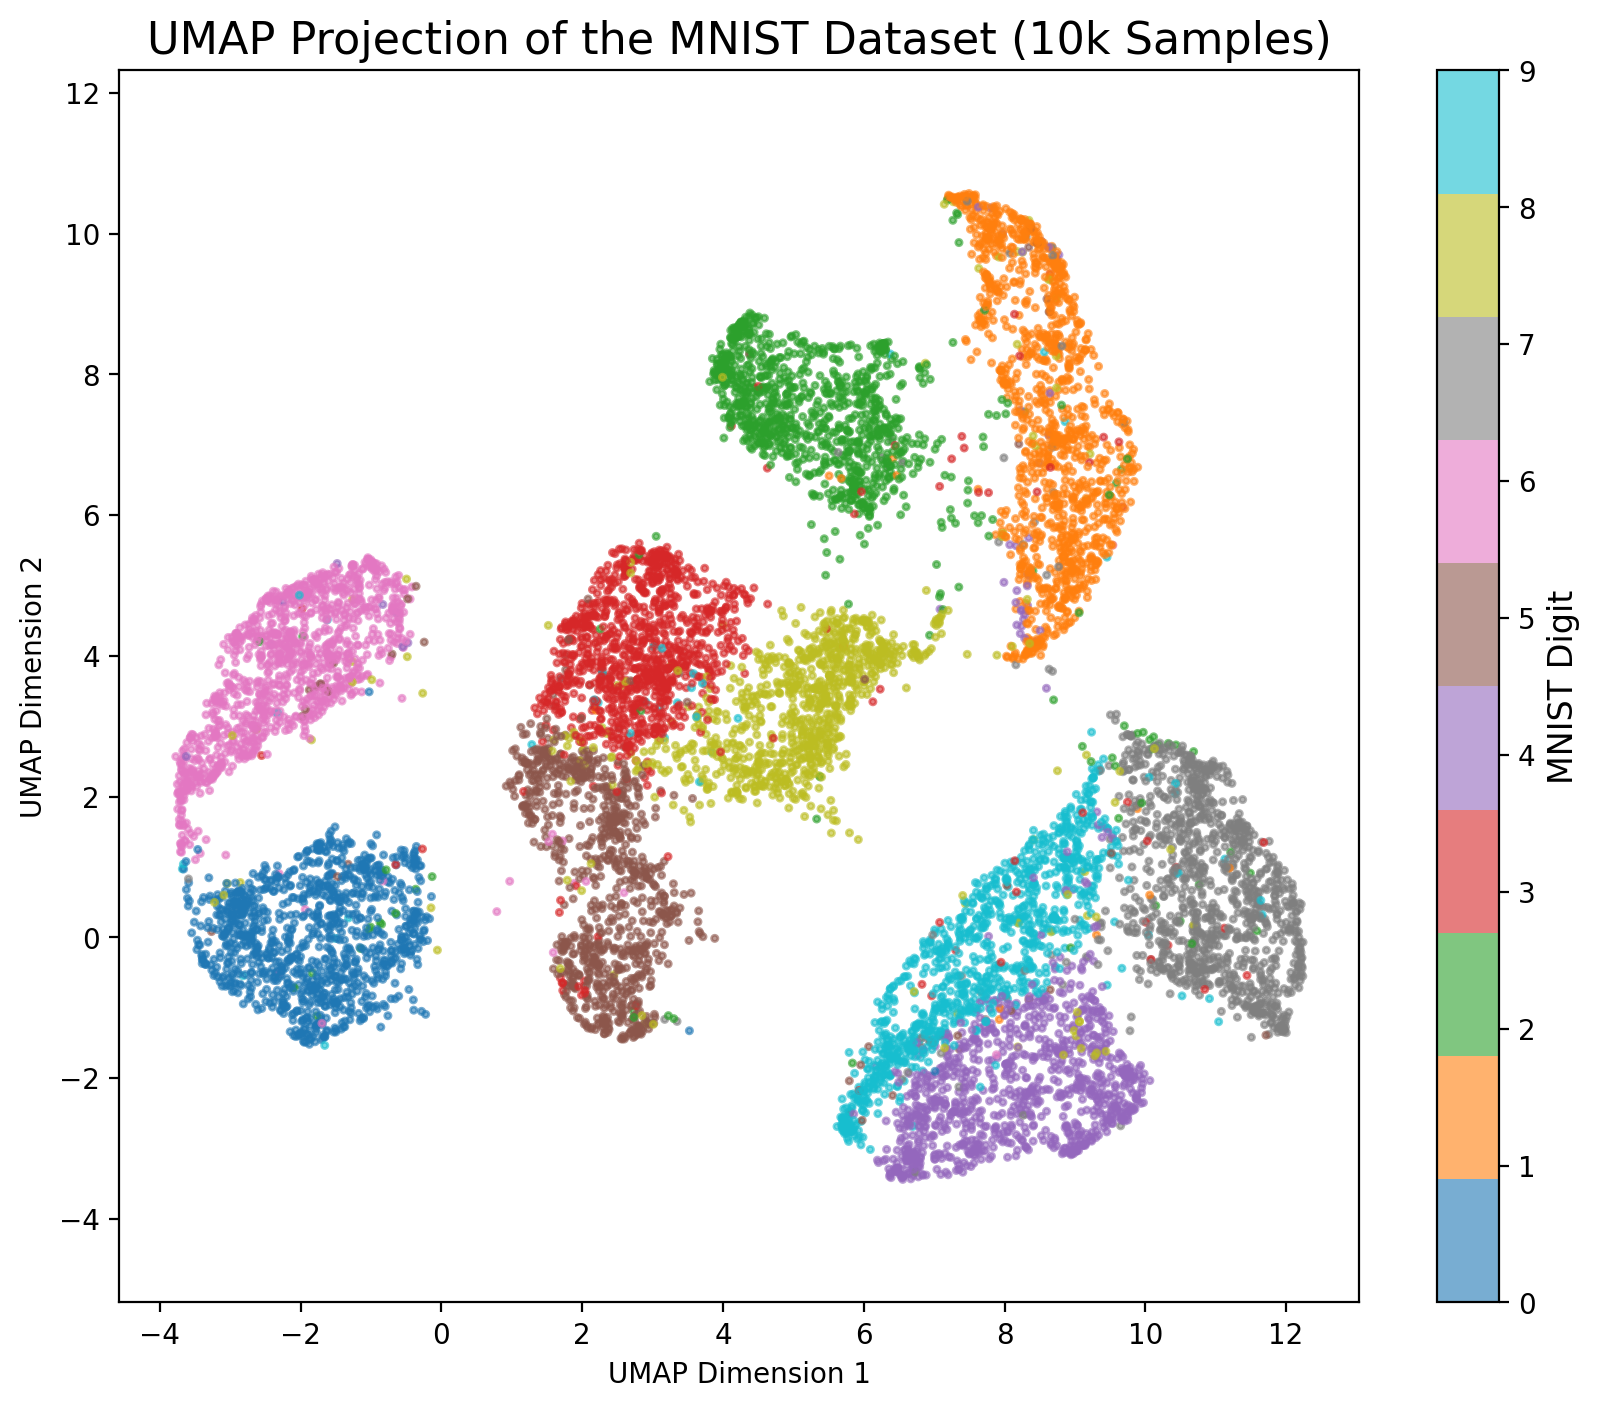

In [9]:
import umap
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Fetch the MNIST dataset (handwritten digits)
print("Loading MNIST dataset (this might take a moment)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto', data_home='/tmp/sklearn_openml')

# To keep execution reasonably fast, sample 10,000 images
X = mnist.data[:10000].astype(np.float32)
y = mnist.target[:10000]

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"Dataset shape: {X.shape}")  # (10000, 784)

# 2. Initialize and run UMAP
print("Running UMAP dimensionality reduction...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    metric='euclidean',
    random_state=42
)

# Fit the data and transform it into a 2D array (10000, 2)
embedding_2d = reducer.fit_transform(X)

# 3. Plot the 2D results
plt.figure(figsize=(10, 8))

# Create a scatter plot colored by the digit label
labels, y_encoded = np.unique(y, return_inverse=True)
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=y_encoded,
    cmap='tab10',
    s=5,
    alpha=0.6
)

# Add a colorbar indicating which color belongs to which class
colorbar = plt.colorbar(scatter, ticks=range(len(labels)))
colorbar.ax.set_yticklabels(labels)
colorbar.set_label('MNIST Digit', fontsize=12)

plt.gca().set_aspect('equal', 'datalim')
plt.title("UMAP Projection of the MNIST Dataset (10k Samples)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

Embedding shape before UMAP transform (333, 4)


Embedding shape after transform (333, 2)


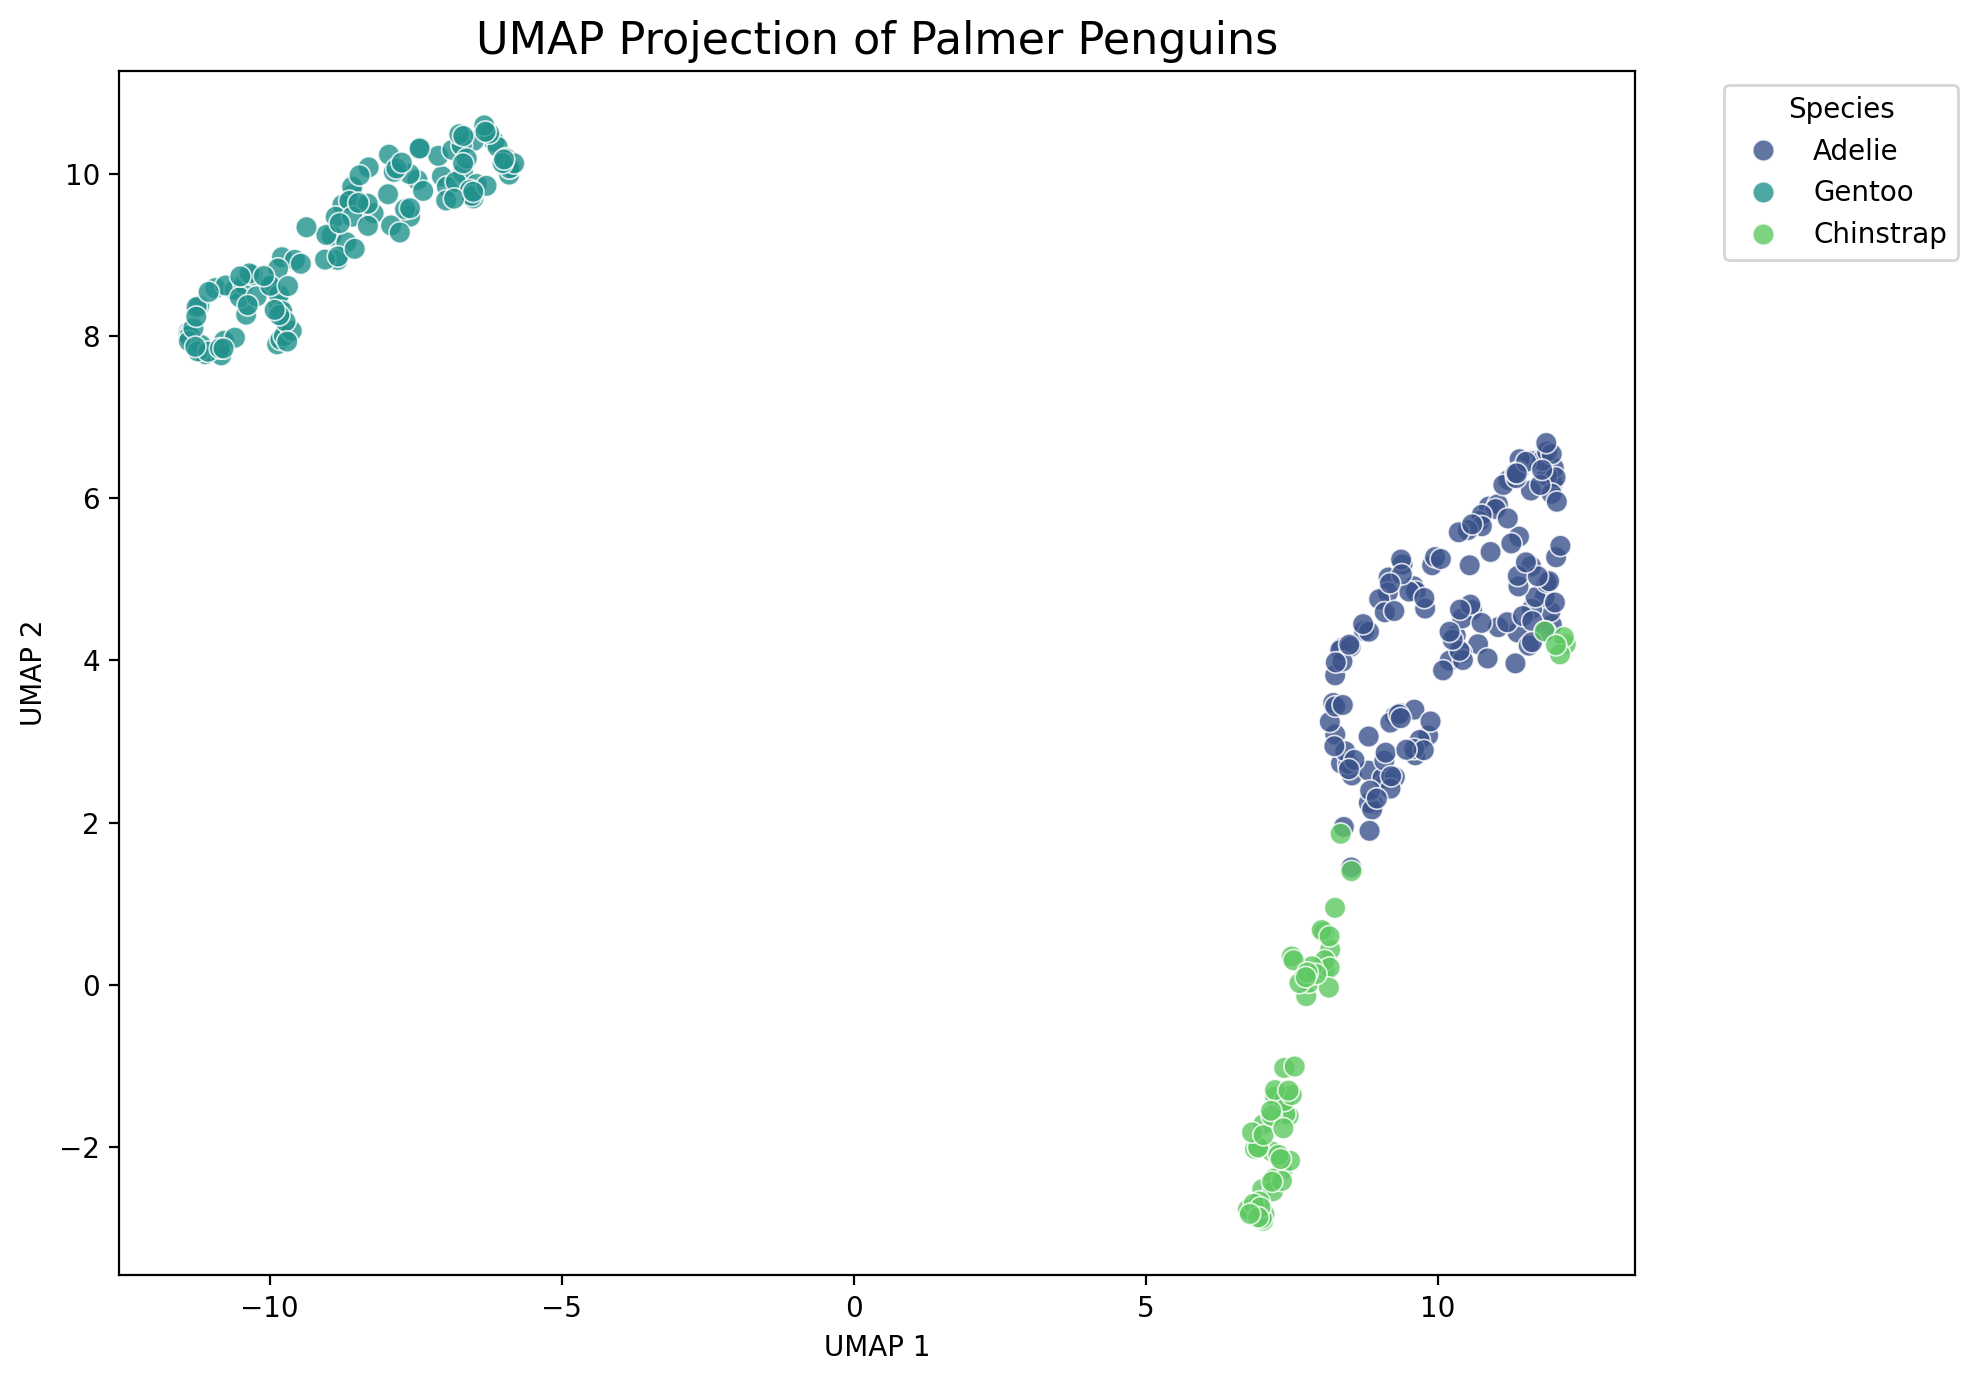

In [8]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from palmerpenguins import load_penguins

# 1. Load the "Relatable" Dataset
penguins = load_penguins()

# 2. Preprocessing
# Drop rows with missing values (real-world data has NaNs!)
penguins = penguins.dropna()

# Select numeric features: Bill length, Bill depth, Flipper length, Body mass
data = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 3. Scaling is MANDATORY for UMAP
# Because 'body_mass_g' is in the thousands while 'bill_depth' is < 25.
scaled_data = StandardScaler().fit_transform(data)

# 4. Fit UMAP
# n_neighbors: balances local vs global structure (15 is a good default)
# min_dist: how tightly points are packed (0.1 is standard)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
print('Embedding shape before UMAP transform', scaled_data.shape)
embedding = reducer.fit_transform(scaled_data)

print('Embedding shape after transform', embedding.shape)

# 5. Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=penguins.species,
    palette='viridis',
    s=60,
    alpha=0.8
)

plt.title('UMAP Projection of Palmer Penguins', fontsize=16)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Experiment with Physical AI**

The steps mentioned above are use the *supervised learn by example* philosophy.  Now use this learning to create a dataset on your own.

*   Record sound of a blender running at different speeds using a smart phone.
*   Trim sound files(.wav) to 1 or 5 second snippets.
*   Create spectrograms of the recorded sound snippets.  
*   Store spectrograms of different speeds in different folders.  Each folder should contain one or more spectrograms of the same speed. Make sure the image size of all the spectrograms is the same.







  